In [65]:
import os, random
from pathlib import Path
from collections import Counter

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

from pathlib import Path

In [39]:
# ====== CONFIG ======
DATA_DIR = "/Users/bhavyabansal/Documents/pbl/scrapnet/master"  
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
SEED = 42
EPOCHS = 12
LR = 1e-4

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(SEED)

Device: mps


In [40]:
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [41]:
# Base dataset just to get labels for stratified split
base_ds = datasets.ImageFolder(DATA_DIR)
classes = base_ds.classes
y = np.array([label for _, label in base_ds.samples])

print("Classes:", classes)
print("Total images:", len(base_ds))

Classes: ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total images: 8134


In [42]:
# Stratified split: 70/15/15
idx = np.arange(len(base_ds))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(idx, y))

y_temp = y[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(sss2.split(temp_idx, y_temp))

val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

print(len(train_idx), len(val_idx), len(test_idx))

5693 1220 1221


In [43]:
train_ds = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(DATA_DIR, transform=val_tfms)
test_ds  = datasets.ImageFolder(DATA_DIR, transform=val_tfms)

train_ds = Subset(train_ds, train_idx)
val_ds   = Subset(val_ds, val_idx)
test_ds  = Subset(test_ds, test_idx)

In [44]:
# Count class distribution in TRAIN only
train_labels = y[train_idx]
counts = Counter(train_labels)

num_classes = len(classes)
total = len(train_labels)

class_weights = np.zeros(num_classes, dtype=np.float32)
for c in range(num_classes):
    class_weights[c] = total / (num_classes * counts[c])

class_weights = torch.tensor(class_weights, device=device)
print("Train class counts:", {classes[k]: v for k, v in counts.items()})
print("Class weights:", class_weights)

Train class counts: {'plastic': 1410, 'glass': 738, 'compost': 639, 'metal': 665, 'paper': 730, 'trash': 1120, 'cardboard': 391}
Class weights: tensor([2.0800, 1.2727, 1.1020, 1.2230, 1.1141, 0.5768, 0.7261],
       device='mps:0')


In [45]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [46]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Replace classifier head
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

In [51]:
def accuracy_from_logits(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_acc = 0.0, 0.0

    for x, yb in loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        total_acc += (preds == yb).float().mean().item()

    return total_loss / len(loader), total_acc / len(loader)
    
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_acc = 0.0, 0.0

    for x, yb in loader:
        x, yb = x.to(device), yb.to(device)
        logits = model(x)
        loss = criterion(logits, yb)

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        total_acc += (preds == yb).float().mean().item()

    return total_loss / len(loader), total_acc / len(loader)

In [52]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1
best_state = None
patience = 3
bad_epochs = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step(va_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("Best val acc:", best_val_acc)

model.load_state_dict(best_state)
model = model.to(device)

Epoch 01 | train loss 0.6534 acc 0.7411 | val loss 0.5257 acc 0.7885
Epoch 02 | train loss 0.4941 acc 0.7989 | val loss 0.4840 acc 0.7981
Epoch 03 | train loss 0.3927 acc 0.8375 | val loss 0.4662 acc 0.8061
Epoch 04 | train loss 0.3226 acc 0.8605 | val loss 0.4693 acc 0.8157
Epoch 05 | train loss 0.2826 acc 0.8778 | val loss 0.4676 acc 0.8133
Epoch 06 | train loss 0.2338 acc 0.9028 | val loss 0.4904 acc 0.8165
Epoch 07 | train loss 0.2063 acc 0.9086 | val loss 0.4784 acc 0.8197
Epoch 08 | train loss 0.1688 acc 0.9301 | val loss 0.5039 acc 0.8157
Epoch 09 | train loss 0.1503 acc 0.9392 | val loss 0.5259 acc 0.8125
Epoch 10 | train loss 0.1236 acc 0.9510 | val loss 0.5481 acc 0.8213
Epoch 11 | train loss 0.1152 acc 0.9550 | val loss 0.5533 acc 0.8165
Epoch 12 | train loss 0.1078 acc 0.9564 | val loss 0.5793 acc 0.8109
Best val acc: 0.8213141025641025


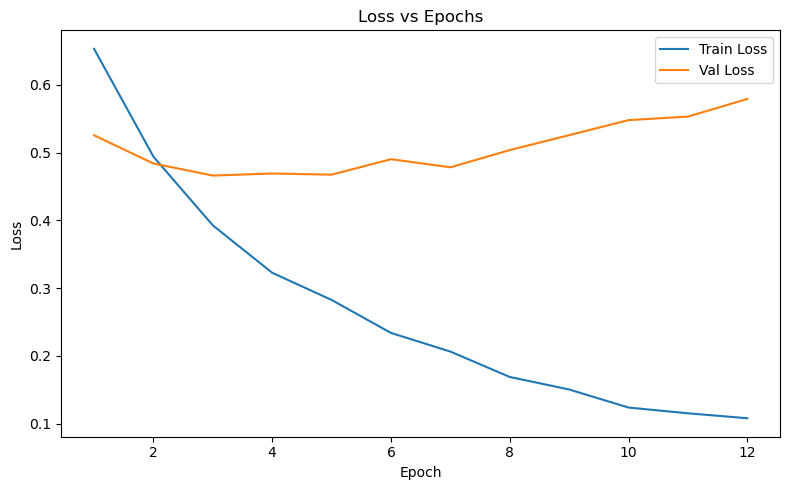

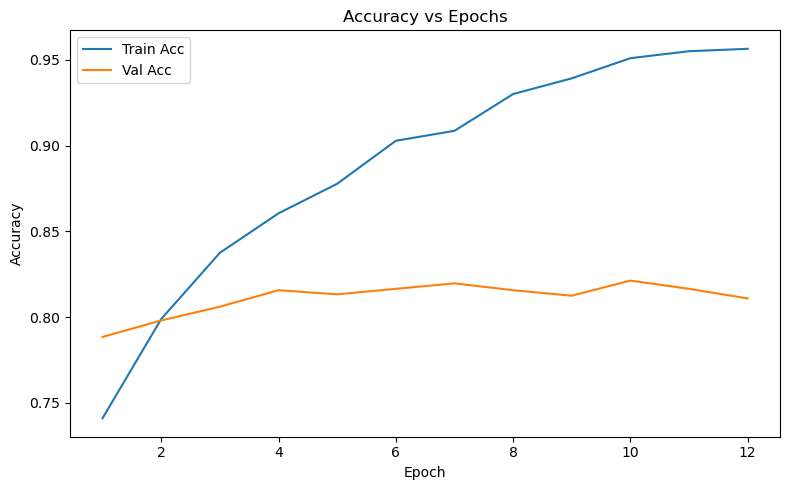

In [66]:
save_dir = Path("artifacts")
save_dir.mkdir(exist_ok=True)

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(save_dir / "loss_curve.png", dpi=300)
plt.show()

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(save_dir / "accuracy_curve.png", dpi=300)
plt.show()

In [54]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_preds, all_true = [], []
    for x, yb in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(list(preds))
        all_true.extend(list(yb.numpy()))
    return np.array(all_true), np.array(all_preds)

y_true, y_pred = predict_all(model, test_loader)

print(classification_report(y_true, y_pred, target_names=classes))
cm=confusion_matrix(y_true, y_pred)
cm

              precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        83
     compost       0.94      0.95      0.94       137
       glass       0.92      0.91      0.92       159
       metal       0.81      0.82      0.82       142
       paper       0.86      0.87      0.86       157
     plastic       0.85      0.78      0.81       302
       trash       0.74      0.81      0.77       241

    accuracy                           0.85      1221
   macro avg       0.86      0.86      0.86      1221
weighted avg       0.85      0.85      0.85      1221



array([[ 75,   0,   0,   0,   4,   3,   1],
       [  1, 130,   1,   0,   0,   2,   3],
       [  0,   1, 145,   2,   1,   8,   2],
       [  0,   0,   2, 117,   3,   5,  15],
       [  2,   0,   2,   0, 136,   7,  10],
       [  4,   3,   5,  14,   4, 235,  37],
       [  1,   5,   2,  11,  10,  17, 195]])

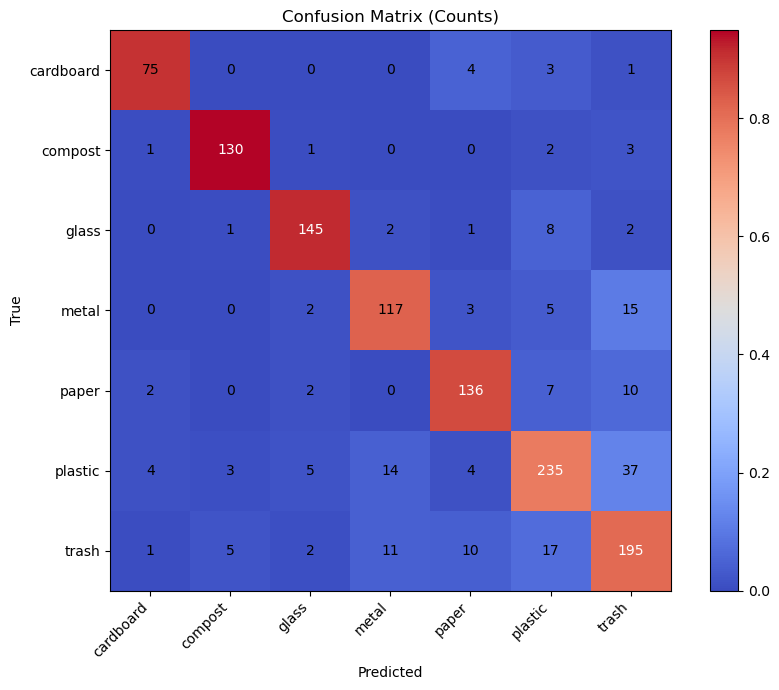

In [69]:
plt.figure(figsize=(9,7))
plt.imshow(cm_norm, cmap='coolwarm')
plt.title("Confusion Matrix (Counts)")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha='right')
plt.yticks(np.arange(len(classes)), classes)

thresh = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]),
                 ha="center", va="center",
                 color="white" if cm[i,j] > thresh else "black")

plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(save_dir / "confusion_matrix_counts.png", dpi=300)
plt.show()

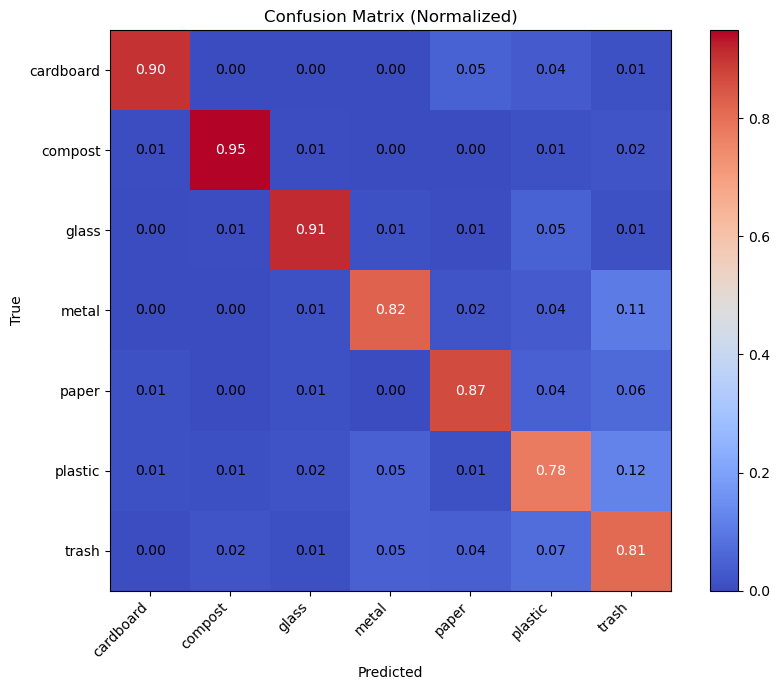

In [70]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9,7))
plt.imshow(cm_norm, cmap='coolwarm')
plt.title("Confusion Matrix (Normalized)")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha='right')
plt.yticks(np.arange(len(classes)), classes)

thresh = cm_norm.max()/2
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i,j]:.2f}",
                 ha="center", va="center",
                 color="white" if cm_norm[i,j] > thresh else "black")

plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(save_dir / "confusion_matrix_normalized.png", dpi=300)
plt.show()

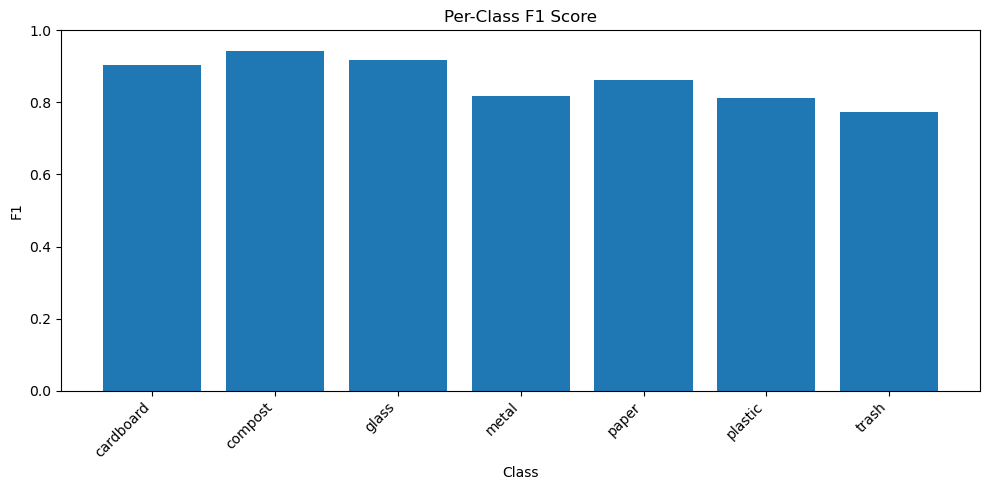

In [71]:
plt.figure(figsize=(10,5))
plt.bar(classes, f1)
plt.title("Per-Class F1 Score")
plt.xlabel("Class")
plt.ylabel("F1")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(save_dir / "f1_scores.png", dpi=300)
plt.show()

In [72]:
import json
from pathlib import Path
import torch

save_dir = Path("artifacts")
save_dir.mkdir(exist_ok=True)

torch.save(model.state_dict(), save_dir / "efficientnet_b0_waste.pth")

with open(save_dir / "classes.json", "w") as f:
    json.dump(classes, f)

print("Model + classes saved in:", save_dir)

Model + classes saved in: artifacts
